# SPARC free-parameter scan: solved electron pressure profiles

Plots every ESCAPE $p_e = n_e T_e$ profile from the free-parameter scan run by
`scan_SCfp_ESCAPE.py`, against the input CGYRO profile.

The scan writes one directory per combination, `neouter<j>_fp<i>`, where `j`
indexes the outer `ne_x0` loop and `i` the free-parameter combination.
Successful runs contain `out_dict.npy`; failures contain `failed.npy` instead,
so globbing for `out_dict.npy` selects exactly the combinations that worked.
The scan may still be running - this notebook plots whatever has finished so
far, so re-run it to pick up new solutions.

Unlike the Yinsen scan, `out_dict` here stores only the raw solver output, so
$p_e$ is reconstructed below from `profiles_solved` ($n_e$ in m$^{-3}$, $T_e$ in
eV) and the input $p_e$ from the saved `manual_profs` ($n_e$ in $10^{20}$
m$^{-3}$, $T_e$ in keV, on a $\rho_\psi = \sqrt{\psi_N}$ grid).

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize

SCAN_DIR = Path('SPARC_workflow')

# Colour each solved profile by one free parameter. Set to None for a single colour.
COLOR_BY = 'alpha_crit'   # 'alpha_crit' | 'C_KBM' | 'De_chie_etg' | 'nFC_x0' | 'ncx_x0_ratio' | None
LOG_COLOR = True          # log colour scale, right for alpha_crit and nFC_x0 (both logspaced in the scan)

e_C = 1.602176634e-19  # J/eV

In [3]:
# p_e reconstruction. The SPARC out_dict stores the solver output directly
# rather than pre-computed pressure curves, so build them here.

def electron_pressure(psi_ne, ne_m3, psi_Te, Te_eV):
    """p_e [Pa] on the density grid, with T_e interpolated onto it."""
    psi_Te, Te_eV = np.asarray(psi_Te, float), np.asarray(Te_eV, float)
    o = np.argsort(psi_Te)
    return np.interp(psi_ne, psi_Te[o], Te_eV[o]) * np.asarray(ne_m3, float) * e_C


def escape_pe(d):
    """ESCAPE (psi_N, p_e [Pa]) on an ascending grid.

    profiles_solved: 'y' is n_e [m^-3] on 'psi_N_ne', 'T_e' is in eV on 'psi_N'.
    """
    s = d['profiles_solved']
    psi = np.asarray(s['psi_N_ne'], float)
    o = np.argsort(psi)
    psi = psi[o]
    return psi, electron_pressure(psi, np.asarray(s['y'], float)[o],
                                  s['psi_N'], s['T_e'])


def input_pe(d):
    """Input (CGYRO) (psi_N, p_e [Pa]) from the saved manual_profs.

    manual_profs: 'ne' [10^20 m^-3] and 'Te' [keV] on psi_N
        ('psi_N_ne'/'psi_N_Te'; scans saved before the psi_N switch
        carry 'rho_ne'/'rho_Te' = sqrt(psi_N) instead).
    """
    p = d['profiles']
    psi_ne = (np.asarray(p['psi_N_ne'], float) if 'psi_N_ne' in p
               else np.asarray(p['rho_ne'], float) ** 2)
    psi_Te = (np.asarray(p['psi_N_Te'], float) if 'psi_N_Te' in p
               else np.asarray(p['rho_Te'], float) ** 2)
    ne = np.asarray(p['ne'], float) * 1e20
    Te_eV = np.asarray(p['Te'], float) * 1e3
    o = np.argsort(psi_ne)
    return psi_ne[o], electron_pressure(psi_ne[o], ne[o], psi_Te, Te_eV)


def zoom_y(ax, x_lo, x_hi=1.0, pad=0.05):
    """Autoscale y over only the data inside [x_lo, x_hi].

    The input profiles run all the way to the magnetic axis, where p_e is an
    order of magnitude above the pedestal, so plain autoscaling would flatten
    the region of interest.
    """
    top = 0.0
    for ln in ax.get_lines():
        x = np.asarray(ln.get_xdata(), float)
        y = np.asarray(ln.get_ydata(), float)
        m = (x >= x_lo) & (x <= x_hi) & np.isfinite(y)
        if m.any():
            top = max(top, float(np.max(y[m])))
    if top > 0:
        ax.set_ylim(0, top * (1 + pad))

In [4]:
# Load every completed scan point.
# Directories are neouter<j>_fp<i>: j indexes the outer ne_x0 loop, i the combination.
def _dir_key(p):
    j, i = p.parent.name.removeprefix('neouter').split('_fp')
    return int(j), int(i)

runs = []
for fp in sorted(SCAN_DIR.glob('neouter*_fp*/out_dict.npy'), key=_dir_key):
    d = np.load(fp, allow_pickle=True).item()
    if d.get('failed'):
        continue
    d['esc_psi'], d['esc_pe'] = escape_pe(d)
    runs.append(d)

n_failed = len(list(SCAN_DIR.glob('neouter*_fp*/failed.npy')))
n_dirs = len(list(SCAN_DIR.glob('neouter*_fp*')))

if not runs:
    raise RuntimeError(f'No completed runs with out_dict.npy found under {SCAN_DIR}')

print(f'{len(runs)} solved, {n_failed} failed, {n_dirs} scan directories present')
print(f'free parameters: {list(runs[0]["free_params"])}')

272 solved, 160 failed, 432 scan directories present
free parameters: ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'ncx_x0_ratio']


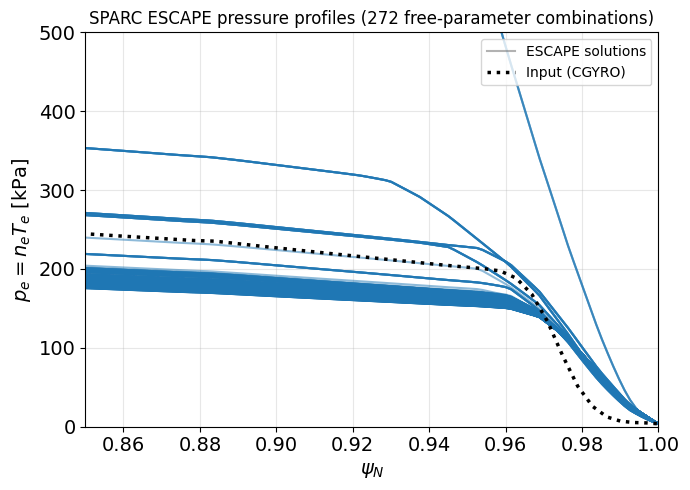

In [6]:
# The input profile is identical for every run
psi_in, pe_in = input_pe(runs[0])

# Colour mapping over the chosen free parameter. Early in the scan the outer
# loop has not advanced yet, so every run can share one value - fall back to a
# single colour rather than build a degenerate norm.
vals = None
colors = ['C0'] * len(runs)
if COLOR_BY is not None:
    vals = np.array([float(r['free_params'][COLOR_BY]) for r in runs])
    if vals.min() != vals.max():
        norm = (LogNorm(vals.min(), vals.max()) if LOG_COLOR and vals.min() > 0
                else Normalize(vals.min(), vals.max()))
        cmap = plt.get_cmap('viridis')
        colors = [cmap(norm(v)) for v in vals]

fig, ax = plt.subplots(figsize=(7, 5))

for r, c in zip(runs, colors):
    # ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
    #         '-', lw=1.5, color=c, alpha=0.5)
    ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
            '-', lw=1.5, color='tab:blue', alpha=0.5)

ax.plot(psi_in, pe_in / 1e3, 'k:', lw=2.5, label='Input (CGYRO)', zorder=10)

# Zoom on the pedestal region the solutions actually cover
psi_min = min(float(np.min(r['esc_psi'])) for r in runs)
ax.set_xlim(psi_min, 1.0)
zoom_y(ax, psi_min)
ax.set_xlabel(r'$\psi_N$', fontsize=14)
ax.set_ylabel(r'$p_e = n_e T_e$ [kPa]', fontsize=14)
ax.set_title(f'SPARC ESCAPE pressure profiles ({len(runs)} free-parameter combinations)')
ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=14)

handles = [plt.Line2D([], [], color='0.4', lw=1.5, alpha=0.5, label='ESCAPE solutions')]
handles += ax.get_legend_handles_labels()[0]
ax.legend(handles=handles, loc='upper right', fontsize=10)

# if vals is not None and vals.min() != vals.max():
#     sm = ScalarMappable(norm=norm, cmap=cmap)
#     sm.set_array([])
#     fig.colorbar(sm, ax=ax, label=COLOR_BY)
ax.set_ylim(0,500)

fig.tight_layout()
plt.show()

In [7]:
# Spread of the solved profiles at the inner edge of the solved region
pe_top = np.array([np.interp(psi_min, np.asarray(r['esc_psi'], float),
                             np.asarray(r['esc_pe'], float)) for r in runs])
pe_in_at = float(np.interp(psi_min, psi_in, pe_in))

print(f'p_e at psi_N = {psi_min:.3f}')
print(f'  input (CGYRO) : {pe_in_at/1e3:8.3f} kPa')
print(f'  ESCAPE min    : {pe_top.min()/1e3:8.3f} kPa')
print(f'  ESCAPE median : {np.median(pe_top)/1e3:8.3f} kPa')
print(f'  ESCAPE max    : {pe_top.max()/1e3:8.3f} kPa')

p_e at psi_N = 0.850
  input (CGYRO) :  244.597 kPa
  ESCAPE min    :  175.651 kPa
  ESCAPE median :  187.914 kPa
  ESCAPE max    : 2012.513 kPa


## Separatrix density free parameters

The separatrix density is set by the two neutral-density free parameters,

$$n_{sep} = n_{FC}(0) + n_{FC}(0)\cdot\frac{n_{CX}(0)}{n_{FC}(0)} = n_{FC}(0)\,\left(1 + \frac{n_{CX}(0)}{n_{FC}(0)}\right)$$

The plots below hold `alpha_crit`, `C_KBM` and `De_chie_etg` fixed and vary only
`nFC_x0` and `ncx_x0_ratio`: first every combination of the two, then each one
separately with the other also held fixed.

In [8]:
from collections import Counter

# Number of (nFC_x0, ncx_x0_ratio) combinations per fixed slice, from the scan grid
N_DENSITY_COMBOS = 4 * 4

# Parameters held fixed while the two density parameters vary.
# Leave a value as None to auto-pick the slice with the most completed runs;
# set it explicitly (e.g. 'De_chie_etg': 0.55) to pin a particular slice.
FIXED = {'alpha_crit': None, 'C_KBM': None, 'De_chie_etg': None}

def par(r, k):
    return float(r['free_params'][k])

def n_sep(r):
    """Separatrix density: nFC(0) + nFC(0) * nCX(0)/nFC(0)."""
    return par(r, 'nFC_x0') * (1.0 + par(r, 'ncx_x0_ratio'))

def select(pool, **constraints):
    """Runs whose free parameters match every non-None constraint."""
    return [r for r in pool
            if all(np.isclose(par(r, k), float(v))
                   for k, v in constraints.items() if v is not None)]

# Resolve any unset fixed value to the combination with the most solved runs,
# so the selection is non-empty while the scan is still filling in.
if any(v is None for v in FIXED.values()):
    counts = Counter(tuple(par(r, k) for k in FIXED) for r in runs)
    best = counts.most_common(1)[0][0]
    FIXED = {k: (v if v is not None else b)
             for (k, v), b in zip(FIXED.items(), best)}

density_runs = select(runs, **FIXED)
if not density_runs:
    raise RuntimeError(f'No solved runs match FIXED = {FIXED}')

print('Holding fixed: ' + ',  '.join(f'{k} = {v:.4g}' for k, v in FIXED.items()))
print(f'{len(density_runs)} of {N_DENSITY_COMBOS} density combinations solved in this slice')
print(f'  nFC_x0       : {np.unique([par(r, "nFC_x0") for r in density_runs])}')
print(f'  ncx_x0_ratio : {np.unique([par(r, "ncx_x0_ratio") for r in density_runs])}')

Holding fixed: alpha_crit = 0.01,  C_KBM = 1,  De_chie_etg = 1
13 of 16 density combinations solved in this slice
  nFC_x0       : [3.16227766e+14 1.46779927e+15 6.81292069e+15 3.16227766e+16]
  ncx_x0_ratio : [ 0.1  1.  10.  20. ]


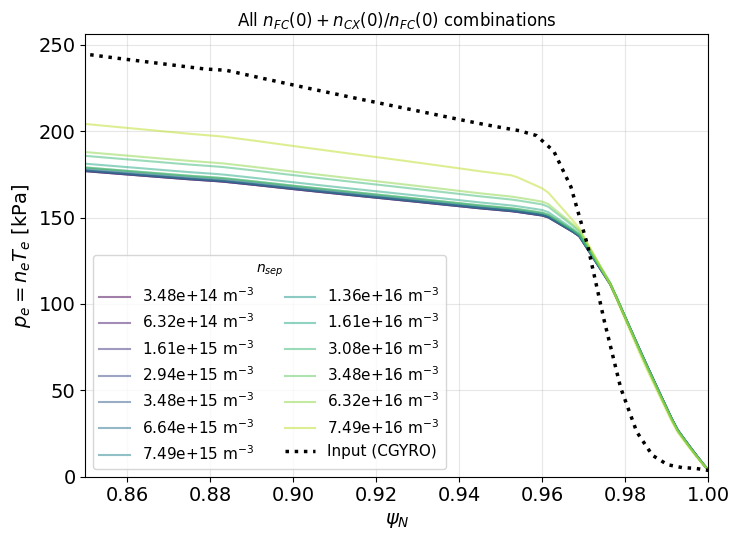

In [9]:
def plot_profiles(ax, group, label_fn, sort_fn, title, legend_title=None, ncol=1):
    """Plot p_e for a group of runs, coloured and legended by one quantity."""
    group = sorted(group, key=sort_fn)
    cols = plt.get_cmap('viridis')(np.linspace(0, 0.9, max(len(group), 1)))

    for r, c in zip(group, cols):
        ax.plot(np.asarray(r['esc_psi'], float), np.asarray(r['esc_pe'], float) / 1e3,
                '-', lw=1.5, color=c, alpha=0.5, label=label_fn(r))

    ax.plot(psi_in, pe_in / 1e3, 'k:', lw=2.5, label='Input (CGYRO)', zorder=10)

    lo = min(float(np.min(r['esc_psi'])) for r in group)
    ax.set_xlim(lo, 1.0)
    zoom_y(ax, lo)
    ax.set_xlabel(r'$\psi_N$', fontsize=14)
    ax.set_ylabel(r'$p_e = n_e T_e$ [kPa]', fontsize=14)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=11, loc='lower left', title=legend_title, ncol=ncol)


# Every combination of nFC(0) and nCX(0)/nFC(0), legended by separatrix density
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_profiles(
    ax, density_runs,
    label_fn=lambda r: rf'{n_sep(r):.2e} m$^{{-3}}$',
    sort_fn=n_sep,
    title=(rf'All $n_{{FC}}(0) + n_{{CX}}(0)/n_{{FC}}(0)$ combinations '),
    legend_title=r'$n_{sep}$', ncol=2,
)
fig.tight_layout()
plt.show()

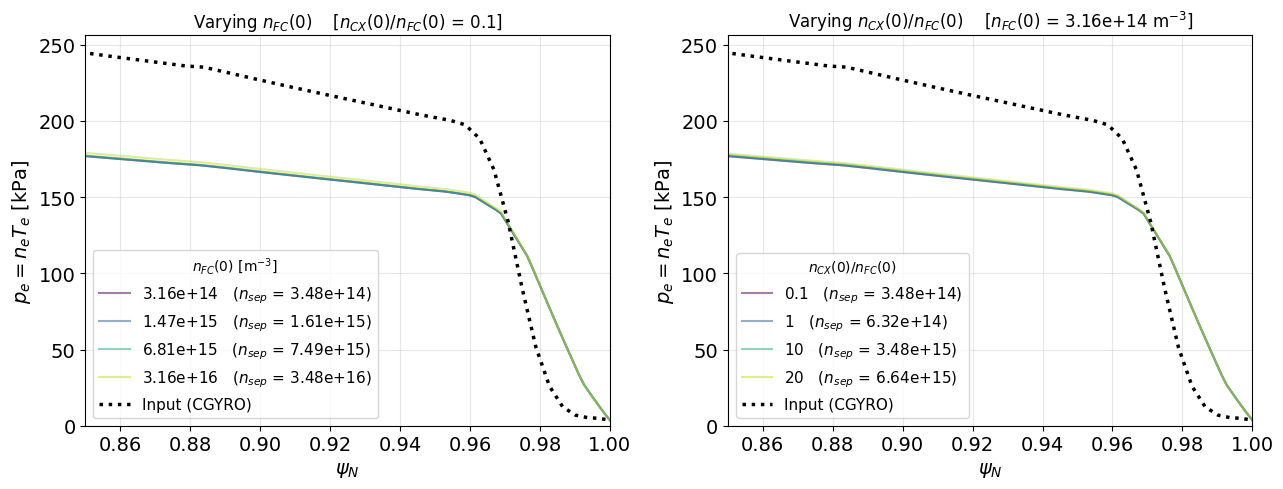

vary nFC(0):            4 runs
vary nCX(0)/nFC(0):     4 runs


In [10]:
# Each density parameter separately, with the other one also held fixed.
# Set either to a specific grid value to pin it; None auto-picks the value with
# the most solved runs in this slice.
NCX_RATIO_FIXED = None   # for the "vary nFC(0)" panel
NFC_X0_FIXED = None      # for the "vary nCX(0)/nFC(0)" panel

if NCX_RATIO_FIXED is None:
    NCX_RATIO_FIXED = Counter(par(r, 'ncx_x0_ratio') for r in density_runs).most_common(1)[0][0]
if NFC_X0_FIXED is None:
    NFC_X0_FIXED = Counter(par(r, 'nFC_x0') for r in density_runs).most_common(1)[0][0]

vary_nFC = select(density_runs, ncx_x0_ratio=NCX_RATIO_FIXED)
vary_ncx = select(density_runs, nFC_x0=NFC_X0_FIXED)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_profiles(
    axes[0], vary_nFC,
    label_fn=lambda r: rf'{par(r, "nFC_x0"):.2e}   ($n_{{sep}}$ = {n_sep(r):.2e})',
    sort_fn=lambda r: par(r, 'nFC_x0'),
    title=(rf'Varying $n_{{FC}}(0)$    '
           rf'[$n_{{CX}}(0)/n_{{FC}}(0)$ = {NCX_RATIO_FIXED:.4g}]'),
    legend_title=r'$n_{FC}(0)$ [m$^{-3}$]',
)

plot_profiles(
    axes[1], vary_ncx,
    label_fn=lambda r: rf'{par(r, "ncx_x0_ratio"):.4g}   ($n_{{sep}}$ = {n_sep(r):.2e})',
    sort_fn=lambda r: par(r, 'ncx_x0_ratio'),
    title=(rf'Varying $n_{{CX}}(0)/n_{{FC}}(0)$    '
           rf'[$n_{{FC}}(0)$ = {NFC_X0_FIXED:.2e} m$^{{-3}}$]'),
    legend_title=r'$n_{CX}(0)/n_{FC}(0)$',
)

fig.tight_layout()
plt.show()

print(f'vary nFC(0):            {len(vary_nFC)} runs')
print(f'vary nCX(0)/nFC(0):     {len(vary_ncx)} runs')

## Solved $T_e$ and $n_e$ profiles

The two profiles that build the pressure, shown separately for a single
free-parameter combination chosen in `CHOICE` below. Any parameter left as
`None` is filled in automatically with the value that has the most solved runs
among the combinations still matching; values given explicitly are snapped to
the nearest one the scan actually solved. The experimental curves come from the
`manual_profs` dict recorded in `out_dict['profiles']` (the SPARC scan stores
the profiles themselves rather than a file path, so nothing needs re-reading
from disk).

Note the solver returns these on different grids: $T_e$ spans the full
$\psi_N$ range in eV, while $n_e$ is given in m$^{-3}$ on the pedestal solve
region only, and its $\psi_N$ grid comes back unsorted.


C_KBM: requested 0.5, snapped to solved value 0.55
De_chie_etg: requested 0.5, snapped to solved value 0.55
Chosen combination:
  alpha_crit    = 10
  C_KBM         = 0.55
  De_chie_etg   = 0.55
  nFC_x0        = 3.162e+14
  ncx_x0_ratio  = 20
  n_sep         = 6.641e+15 m^-3


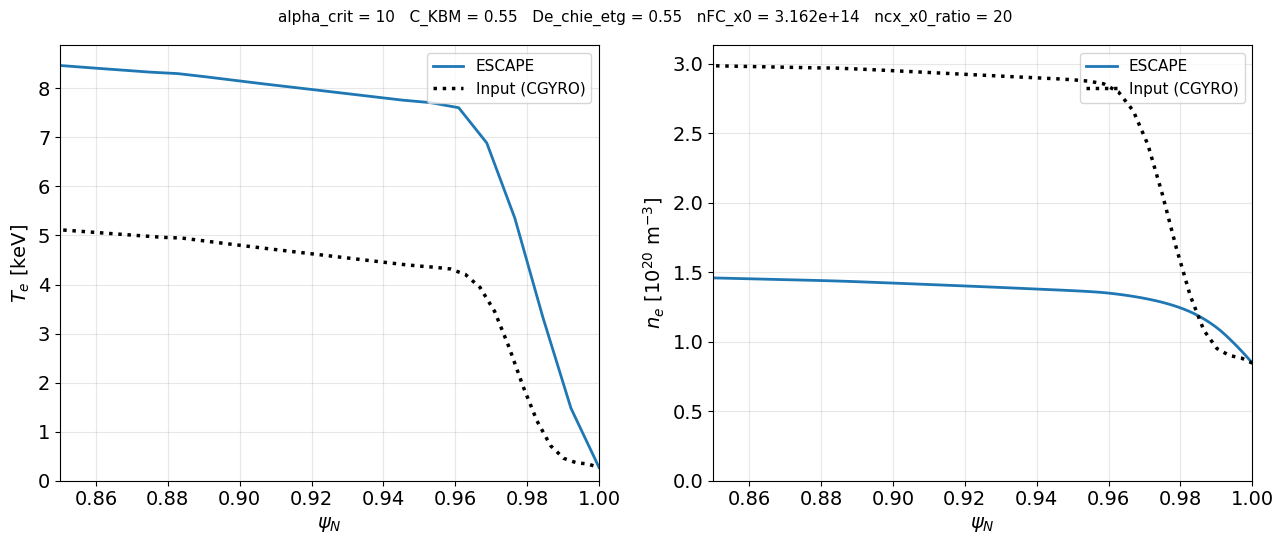

In [12]:
def input_profiles(d):
    """Experimental T_e [keV] and n_e [10^20 m^-3] on psi_N, from manual_profs."""
    p = d['profiles']
    psi_Te = (np.asarray(p['psi_N_Te'], float) if 'psi_N_Te' in p
               else np.asarray(p['rho_Te'], float) ** 2)
    psi_ne = (np.asarray(p['psi_N_ne'], float) if 'psi_N_ne' in p
               else np.asarray(p['rho_ne'], float) ** 2)
    return {
        'Te_psi': psi_Te, 'Te': np.asarray(p['Te'], float),
        'ne_psi': psi_ne, 'ne': np.asarray(p['ne'], float),
    }

pf = input_profiles(runs[0])


def solved_Te(r):
    """ESCAPE T_e [keV] on its own psi_N grid."""
    s = r['profiles_solved']
    return np.asarray(s['psi_N'], float), np.asarray(s['T_e'], float) / 1e3

def solved_ne(r):
    """ESCAPE n_e [10^20 m^-3], sorted onto an ascending psi_N grid."""
    s = r['profiles_solved']
    psi = np.asarray(s['psi_N_ne'], float)
    o = np.argsort(psi)
    return psi[o], np.asarray(s['y'], float)[o] / 1e20


# --- Pick one free-parameter combination -------------------------------------
# Set an entry to the value you want; it is snapped to the nearest value on the
# scan grid (in log space, since alpha_crit and nFC_x0 are logspaced) and is
# then *required*: if that exact combination was not solved the cell says so
# rather than quietly substituting a different one. Leave an entry None to have
# it filled in with the value that has the most solved runs among the
# combinations matching everything that was asked for.
CHOICE = {
    'alpha_crit':   10,
    'C_KBM':        0.5,
    'De_chie_etg':  0.5,
    'nFC_x0':       None,   # 5e15 snaps to 6.81e15, where ncx_x0_ratio = 20 was not solved
    'ncx_x0_ratio': 20,
}

FREE_PARAMS = list(runs[0]['free_params'])

def grid(k, pool=None):
    """The values of `k` the scan actually solved (within `pool`, if given)."""
    return np.unique([par(r, k) for r in (runs if pool is None else pool)])

def snap(k, v):
    """Nearest solved value of `k`, in log space for the logspaced grids."""
    g = grid(k)
    d = (np.abs(np.log(g) - np.log(float(v))) if g.min() > 0 and float(v) > 0
         else np.abs(g - float(v)))
    return float(g[np.argmin(d)])

def resolve_choice(choice):
    """Complete `choice` into one combination the scan solved.

    The requested values are applied together as hard constraints, so a
    parameter can never be overruled by one that happens to come earlier in
    FREE_PARAMS - the scan is far from a complete grid, and narrowing one
    parameter at a time would silently move a later request onto whatever
    value survived. Unset parameters are filled in afterwards, against the
    runs that match the request.
    """
    want = {}
    for k, v in choice.items():
        if v is None:
            continue
        want[k] = snap(k, v)
        if not np.isclose(want[k], float(v)):
            print(f'{k}: requested {float(v):.4g}, snapped to solved value {want[k]:.4g}')

    pool = select(runs, **want)
    if not pool:
        msg = ['No solved run has ' +
               ',  '.join(f'{k} = {v:.4g}' for k, v in want.items())]
        for k in want:            # what relaxing one request on its own would allow
            got = grid(k, select(runs, **{j: u for j, u in want.items() if j != k}))
            if len(got):
                msg.append(f'  holding the others, {k} was solved at '
                           + ', '.join(f'{v:.4g}' for v in got))
        raise RuntimeError('\n'.join(msg))

    chosen = dict(want)
    for k in FREE_PARAMS:         # fill the unset ones from what is left
        if k not in chosen:
            chosen[k] = Counter(par(r, k) for r in pool).most_common(1)[0][0]
            pool = select(pool, **{k: chosen[k]})
    return {k: chosen[k] for k in FREE_PARAMS}, pool

CHOSEN, chosen_runs = resolve_choice(CHOICE)
run = chosen_runs[0]

print('Chosen combination:')
for k, v in CHOSEN.items():
    print(f'  {k:13s} = {v:.4g}')
print(f'  n_sep         = {n_sep(run):.3e} m^-3')


def plot_one(ax, r, getter, ref_x, ref_y, ylabel, xlim_lo=None):
    """One solved profile against the input (CGYRO) curve."""
    x, y = getter(r)
    ax.plot(x, y, '-', lw=2.0, color='tab:blue', label='ESCAPE')
    ax.plot(ref_x, ref_y, 'k:', lw=2.5, label='Input (CGYRO)', zorder=10)

    lo = xlim_lo if xlim_lo is not None else float(np.min(x))
    ax.set_xlim(lo, 1.0)
    zoom_y(ax, lo)
    ax.set_xlabel(r'$\psi_N$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=11, loc='upper right')


# Same x range convention as the pressure plots: the region n_e is solved on
psi_lo = float(np.min(solved_ne(run)[0]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plot_one(axes[0], run, solved_Te, pf['Te_psi'], pf['Te'],
         r'$T_e$ [keV]', xlim_lo=psi_lo)

plot_one(axes[1], run, solved_ne, pf['ne_psi'], pf['ne'],
         r'$n_e$ [$10^{20}$ m$^{-3}$]', xlim_lo=psi_lo)

fig.suptitle('   '.join(f'{k} = {v:.4g}' for k, v in CHOSEN.items()), fontsize=11)
fig.tight_layout()
plt.show()


## Convergence rate across the free-parameter scan

Corner plot of how robust the solve is to the free-parameter choice. The
multi-equilibria version of this figure colours each cell by the percentage of
*equilibria* whose fit reached $L_2 \\le 0.05$; there is only one equilibrium
here, so the ensemble is the scan grid itself and each cell shows the percentage
of scan points at that pair of parameter values that produced a **converged**
run - `out_dict.npy` rather than `failed.npy` - marginalised over the three free
parameters not on its axes. The diagonal shows the same quantity one parameter
at a time.

272 of 432 finished scan points converged (63%)


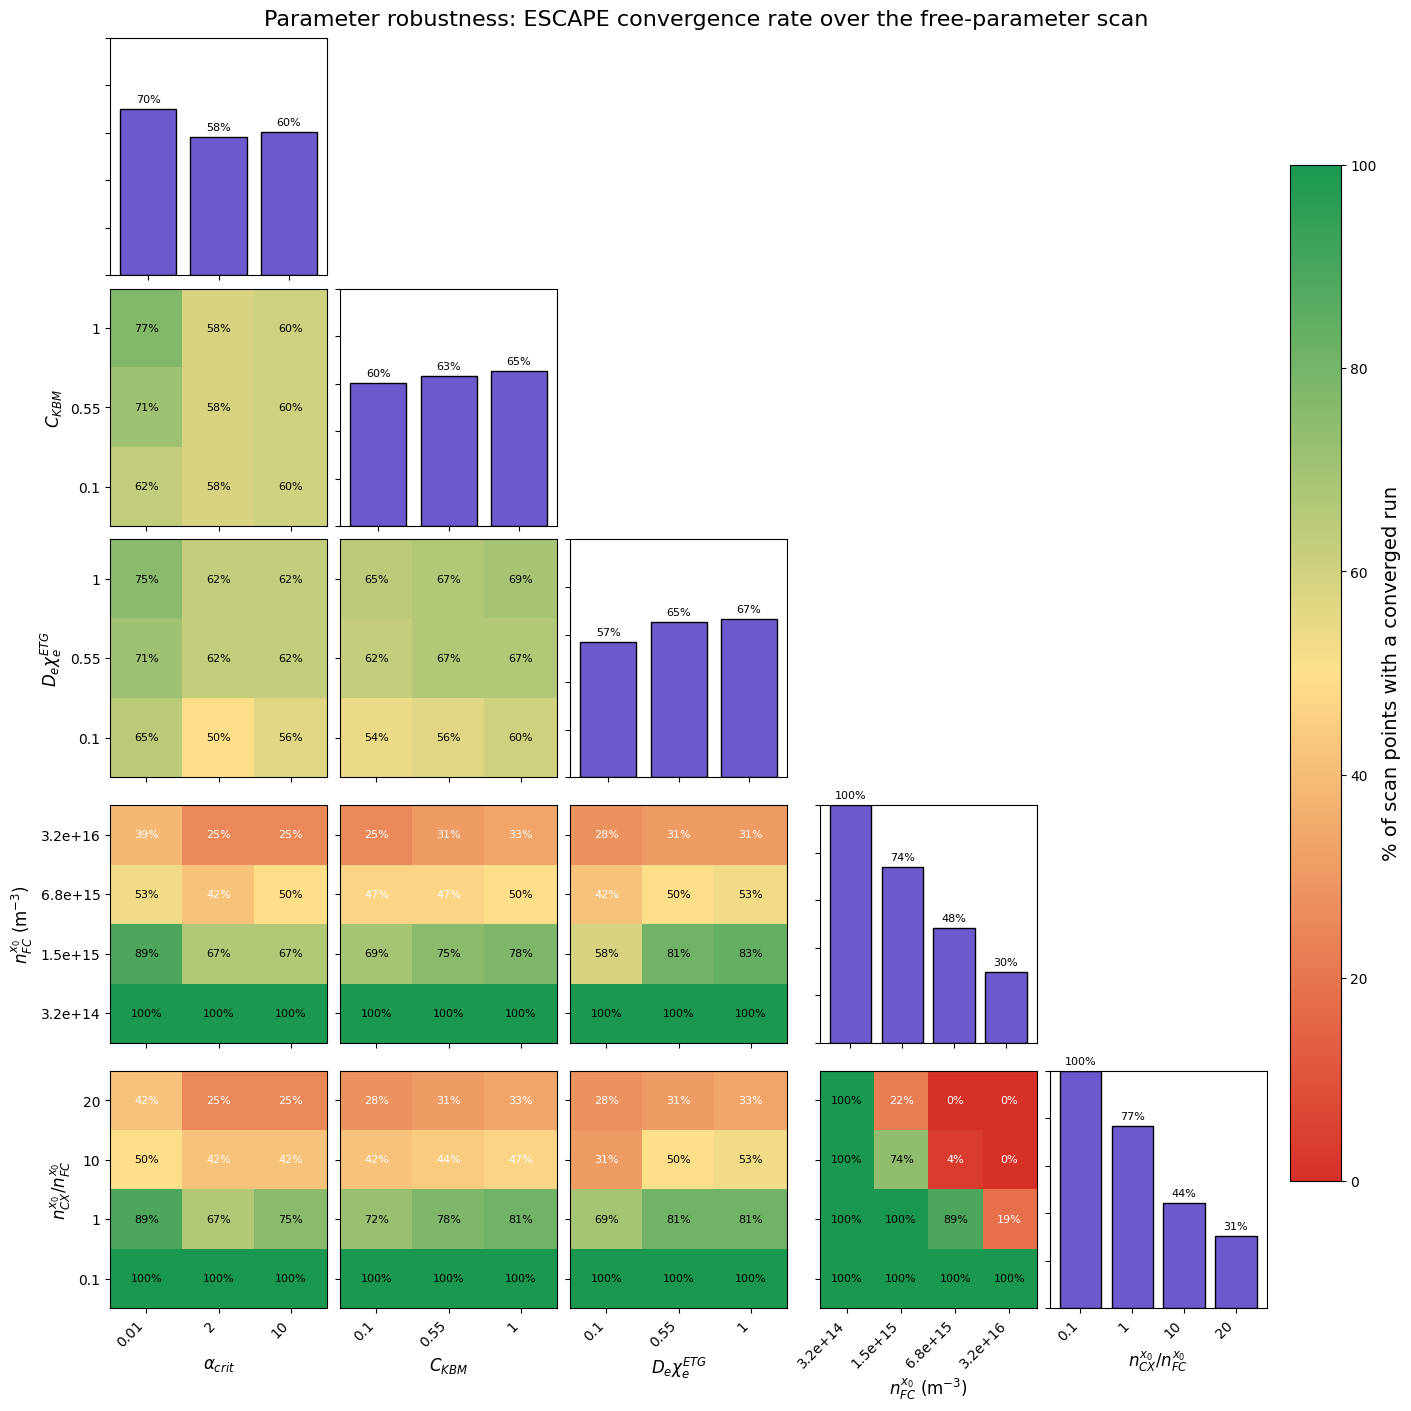

In [13]:
# --- Convergence rate over the free-parameter grid ----------------------------
# Corner plot of how often the solver converged. The multi-equilibria version of
# this figure averages over an ensemble of equilibria; here there is a single
# SPARC equilibrium, so the ensemble is the scan grid itself: each cell is the
# percentage of scan points at that pair of values that produced an out_dict
# (i.e. converged), marginalised over the three free parameters not on its axes.
# The diagonal is the same figure of merit for one parameter at a time.
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib import cm

# Every finished scan point, converged or not: successes write out_dict.npy,
# failures write failed.npy, and both record the free parameters that were used.
scan = []
for dpath in sorted(SCAN_DIR.glob('neouter*_fp*')):
    fp = next((dpath / f for f in ('out_dict.npy', 'failed.npy')
               if (dpath / f).exists()), None)
    if fp is None:
        continue                                  # combination not run yet
    d = np.load(fp, allow_pickle=True).item()
    scan.append((dict(d['free_params']), not d.get('failed', False)))

if not scan:
    raise RuntimeError(f'No finished scan points under {SCAN_DIR}')

PARAMS = list(scan[0][0])
PARAM_LABELS = {
    'alpha_crit':   r'$\alpha_{crit}$',
    'C_KBM':        r'$C_{KBM}$',
    'De_chie_etg':  r'$D_e\chi_e^{ETG}$',
    'nFC_x0':       r'$n_{FC}^{x_0}$ (m$^{-3}$)',
    'ncx_x0_ratio': r'$n_{CX}^{x_0}/n_{FC}^{x_0}$',
}
grids = [np.unique([float(f[k]) for f, _ in scan]) for k in PARAMS]
N = len(PARAMS)

n_ok = sum(ok for _, ok in scan)
print(f'{n_ok} of {len(scan)} finished scan points converged '
      f'({100 * n_ok / len(scan):.0f}%)')

# Pairwise tallies: n_run[i][j][a, b] scan points with PARAMS[i] at grids[i][a]
# and PARAMS[j] at grids[j][b], n_conv[i][j][a, b] how many of them converged.
shape = lambda i, j: (len(grids[i]), len(grids[j]))
n_run = [[np.zeros(shape(i, j)) for j in range(N)] for i in range(N)]
n_conv = [[np.zeros(shape(i, j)) for j in range(N)] for i in range(N)]

for f, ok in scan:
    idx = [int(np.argmin(np.abs(g - float(f[k])))) for k, g in zip(PARAMS, grids)]
    for i in range(N):
        for j in range(N):
            n_run[i][j][idx[i], idx[j]] += 1
            n_conv[i][j][idx[i], idx[j]] += ok

# Red -> yellow -> green, 0 % to 100 % converged
cmap = LinearSegmentedColormap.from_list(
    'RdYlGn_custom', ['#d73027', '#fee08b', '#1a9850'])
norm = Normalize(vmin=0, vmax=100)

def tick_labels(g):
    return [f'{v:.1e}' if v > 1000 else f'{v:g}' for v in g]

fig, axes = plt.subplots(N, N, figsize=(14, 14), constrained_layout=True)

for i in range(N):
    for j in range(N):
        ax = axes[i, j]
        if j > i:                                  # lower triangle only
            ax.axis('off')
            continue

        # Percentage converged, with cells the scan never reached left blank
        with np.errstate(invalid='ignore'):
            pct = np.where(n_run[i][j] > 0,
                           100 * n_conv[i][j] / np.maximum(n_run[i][j], 1), np.nan)

        if i == j:
            bars = np.diag(pct)
            ax.bar(range(len(grids[i])), bars, color='slateblue', edgecolor='k')
            ax.set_ylim(0, 100)
            ax.set_xticks(range(len(grids[j])))
            for b, p in enumerate(bars):
                if np.isfinite(p):
                    ax.text(b, p + 2, f'{p:.0f}%', ha='center', va='bottom', fontsize=8)
        else:
            ax.imshow(np.ma.masked_invalid(pct), cmap=cmap, norm=norm,
                      origin='lower', aspect='auto')
            ax.set_xticks(range(len(grids[j])))
            ax.set_yticks(range(len(grids[i])))
            for a in range(len(grids[i])):
                for b in range(len(grids[j])):
                    p = pct[a, b]
                    if not np.isfinite(p):
                        continue
                    ax.text(b, a, f'{p:.0f}%', ha='center', va='center',
                            color='white' if p < 50 else 'black', fontsize=8)

        ax.set_xticklabels(tick_labels(grids[j]), rotation=45, ha='right')
        if i == N - 1:
            ax.set_xlabel(PARAM_LABELS[PARAMS[j]], fontsize=12)
        else:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(PARAM_LABELS[PARAMS[i]], fontsize=12)
            ax.set_yticklabels(tick_labels(grids[i]))
        else:
            ax.set_yticklabels([])

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, location='right', pad=0.02)
cbar.set_label('% of scan points with a converged run', fontsize=14)

fig.suptitle('Parameter robustness: ESCAPE convergence rate over the free-parameter scan',
             fontsize=16)
fig.savefig('convergence_corner_SPARC.png', dpi=300)
plt.show()